## Gaussian Mixture Models
### The Set-Up
#### 0. Math Crash Course: Why is a "Gaussian Blob" ellipsoids? (<i>plural</i>, because level sets)
In multivariate Gaussian distribution, for $x \in \mathbb{R}^d$ the probability density is,<br><br>
$f(x) = \frac{1}{(2 \pi)^{d/2} |\Sigma|^{1/2}}\: exp \: (-\frac{1}{2}(x - \mu)^\top \Sigma ^{-1} (x - \mu))\:\:\:$, where<br>
- $\mu$ is the mean,
- $\Sigma$ is the covariance matrix ($|\Sigma|$ denotes the determinant), and
- together, the quadratic form $(x - \mu)^\top \Sigma ^{-1} (x - \mu)$ controls the shape of the distribution.
> <strong>REMARK</strong><br>
<i>Matrix exponential</i> is defined as<br><br>
$exp(\mathbf{A}) = \sum_{k=0}^{\infty} \mathbf{A}^k = \mathbf{I} + \mathbf{A} + \frac{1}{2!}\mathbf{A}^2 + \frac{1}{3!}\mathbf{A}^3 \dots$<br><br>
That said, the term $(x - \mu)^\top \Sigma ^{-1} (x - \mu)$ after matrix operation actualy ends up being a scaler.

Now consider the <strong>level sets</strong>. Since the scaling $\frac{1}{(2 \pi)^{d/2} |\Sigma|^{1/2}}$ is constant, for simplicity, we just look at the quadratic form:<br>

$c = (x - \mu)^\top \Sigma ^{-1} (x - \mu) \:\:$ for some $c > 0$.<br>

A few simple cases first:<br>
- If $\Sigma = \mathbf{I}$, then<br>

$\:\:\:\:\: \:\:\:\:\:\: c = (x - \mu)^\top \Sigma ^{-1} (x - \mu) = (x - \mu)^\top (x - \mu) = \left\Vert x - \mu\right\Vert^2$.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;This is a sphere centered at $\mu$.
- If $\Sigma_{ij} = 0 \:\:\: \forall \: i \neq j$, i.e., all off-diagonal elements are zero. Let $\Sigma^{-1} = \text{diag}(\lambda^{-1}_1, \dots , \lambda^{-1}_d)$, then<br><br>
$c = \sum_{k=1}^{d} \:\lambda^{-1}_k (x_k - \mu_k)(x_k - \mu_k) = \sum_{k=1}^{d} \frac{1}{\lambda_k}(x_k - \mu_k)^2$<br><br>
This is an ellipsoid centered at $\mu = (\mu_1, \dots \mu_d)$ that is <strong>axis-aligned.</strong> (i.e., aligned with the Canonical basis / standard basis $\{e_1, e_2, \dots , e_d\}$)<br><br>

Now what if $\Sigma$ has off-diagonal elements? Good news is, $\Sigma$ is a covariance matrix, meaning $\Sigma = X^\top X$ for some centered data matrix X. As such, $\Sigma$ is synmmetric and positive semidefinite with non-negative eigen values. And for the inverse to be well defined, here we assume <i>positive definite</i>. We can therefore factor $\Sigma$ into its eign decomposion<br>

$\Sigma = Q\Lambda Q^\top$, $\:\:\Sigma^{-1} = Q\Lambda^{-1} Q^\top$<br>

where columns of $Q$ form an orthonormal eigen basis of $\mathbb{R}^d$ i.e., it consists of unit eigen vectors of $\Sigma$: $v_1, v_2, \dots , v_d$
> Note that $Q^\top Q = Q Q^\top = \mathbf{I}$, this means that the linear transformation <strong>preserves lengths and angles</strong>. So put more precisely, $Q$ is an <strong>orthogonal change of coordinates</strong>, and is geometrically a <strong>rotation or refelction</strong>. 

Plugging the eigen decomposition into the level sets, we have

$c = (x - \mu)^\top \Sigma ^{-1} (x-\mu) = (x - \mu)^\top Q \Lambda^{-1} Q^\top (x - \mu) = (Q^\top (x - \mu))^\top \Lambda^{-1} Q^\top (x - \mu)$<br>

Let $z = Q^\top x, \:\: \mu^\prime = Q^\top\mu$, then $z, \: \mu^\prime$ represents the coordinates of $x$ and $\mu$ (respectively) rotated in such a way that it aligns with the eigen vector directions. So we now have the following

$c = (x - \mu)^\top \Sigma ^{-1} (x-\mu) = (z - \mu^\prime)^\top \Lambda^{-1} (z-\mu^\prime) = \sum_{k=1}^{d} \frac{1}{\Lambda_k}(z_{k} - \mu_k^\prime)^2$, which, again, is an ellipsoid.<br><br>

<strong>So in sum, the principal axes of ellipsoid point in the directions of the eigen vectors of the covariance matrix, and the corresponding eigen values determine how "strached" the ellipsoid is in that direction. If the covariance matrix has non-zero off-diagonal values, then the ellipsoid is not axis aligned with the original coordinate system, but is rotated in line with the eigen basis corrdinate system.</strong>

#### 1. The Generative Story
Let the mixture model parameters be

$\{\pi_k, \mu_k, \Sigma_k\}_{k=1}^{K}$, with $\pi_k \ge 0, \:\:\: \sum_{k=1}^{K} \pi_k = 1$

Then for each point (observation) $x_n$, draw a latent cluster label $z_n \sim \text{Categorical}(\pi_1, \dots, \pi_k)$. So $z \in \{1, \dots, K\}$ and $p(z = k) = \pi_k$.<br>

If $z_n = k$, then $x_n \sim \mathcal{N}(\mu_k, \Sigma_k)$. Or more compactly,<br>
$x_n \mid z_n = k \sim \mathcal{N}(\mu_k, \Sigma_k)$.

Equivalently (and for later convenience), we define <i>one-hot-encode latent variables</i> $z_n = z_{n1}, \dots, z_{nK}\:$ such that if $z_n = k$<br>
$z_{nk} = 1$<br>
$z_{nj} = 0$ , $\: \forall \: j \neq k, \:\:$ and

$p(x_n, \: z_n) = \prod_{k=1}^{K} \pi_k \: \mathcal{N} (x_n \mid \mu_k, \Sigma_k) ^ {z_{nk}}$<br>
$p(x_n \mid z_n) = \prod_{k=1}^{K} \mathcal{N} (x_n \mid \mu_k, \Sigma_k) ^ {z_{nk}}$

> Note that here $z_{nk}$ functions as the exponent analogy of the Kroneocker delta.
#### 2. Maximizing Likelihood
In the observed data, the <i>latent variables</i> are unknown. Thus, we marginalize $z$ out and compute the marginalized distribution

$p(x_n) = \sum_{z_{n}} p(x_n, z_n) = \sum_{z_{n}} \prod_{k=1}^{K} \pi_k \:\mathcal{N} (x_n \mid \mu_k, \Sigma_k)^{z_{nk}} = \sum_{k=1}^{K} \pi_k \:\mathcal{N} (x_n \mid \mu_k, \Sigma_k)$


Thus, the objective is to maximize the likelihood of observing the data given parameters<br>

and $\theta := \{\pi_k, \mu_k, \Sigma_k\}_{k=1}^{K}$<br>

writing the conditional on $\theta$ more explicitly, we have<br>

$p(X \mid \theta) = \prod_{n=1}^{N} \sum_{k=1}^{K} \pi_k \:\mathcal{N} (x_n \mid \mu_k, \Sigma_k)$

Then taking log

$log \:p(X \mid \theta) = \sum_{n=1}^{N} log \left[ \sum_{k=1}^{K} \pi_k \:\mathcal{N} (x_n \mid \mu_k, \Sigma_k) \right]$<br>

we see that log of sums is generally messier to maximize directly (when we take its derivative, $\mu$, $\pi$, and $\Sigma$ all get entangld). As such, we introduce <i>responsibilities</i> and <i>soft assignments</i>, which are the core of the algorithms's E-step and M-step iterations, during the latter of which $\mu$, $\pi$, and $\Sigma$ the compose cleanly.

#### 3. E-step

Define <strong>responsibility</strong> as follows

$r_{nk} := p(z_n = k \mid x_n, \theta^\text{old}),\:\:\:$ i.e., given this data point and old parameters $\theta^\text{old}$ $x_n$, what is the probability of $x_n$ coming from cluster $k$?

Then we can aggregate the responsibilities over all data points

$N_{k} = \sum_{n=1}^{N} r_{nk}$

Note also that we have the desirable property

$\mathbb{E}[z_{nk} \mid x_n, \theta^\text{old}] = 0 \cdot p(z_{nk} = 0 \mid x_n, \theta^\text{old}) + 1 \cdot p(z_{nk} = 1 \mid x_n, \theta^\text{old}) = p(z_{n} = k \mid x_n , \theta^\text{old}) = r_{nk}$.



#### 4. M-Step

Now consider the <i>complete data joint probability</i>

$p(X, Z \mid \theta) = \prod_{n=1}^{N} \prod_{k=1}^{K} \pi_k \mathcal{N} (x_n \mid \mu_k, \Sigma_k)^{z_{nk}}$

Again taking log

$log\ p(X, Z \mid \theta) = \sum_{n=1}^{N} \sum_{k=1}^{K} z_{nk} \left[ \: log \pi_k + \:log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)\right]$<br><br>

Define <strong>the expected complete-data log-likelihood</strong> $Q(\theta, \theta^\text{old})$ by taking expectation over $Z$ conditional on $X$ and $\theta^\text{old}$

$Q(\theta, \theta^\text{old}) := \mathbb{E}_{Z \mid X, \theta^\text{old}} \left[ log\ p(X, Z \mid \theta) \right]$<br>
$= \sum_{n=1}^{N} \sum_{k=1}^{K} \left[log \pi_k  +\:log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)\right] \cdot \mathbb{E}_{Z \mid X, \theta^\text{old}}\left[z_{nk} \mid x_n, \theta^\text{old} \right]$<br>
$=\sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \left[ log \pi_k + \:log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)\right]$<br>
$=\sum_{k=1}^{K} log \pi_k \sum_{n=1}^{N} r_{nk} + \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \:log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)$<br>
$=\sum_{k=1}^{K} N_{k} \ log \pi_k + \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk} \:log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)$<br>

This is what a Gaussia Mixture Model aims to maximize, i.e.,<br>

$\text{maximize}_{\pi, \mu, \Sigma} \:\:\:\:\:\:\:\:\: Q(\theta, \theta^{\text{old}})$<br>
$\text{subject to} \:\:\:\:\:\:\:\:\:\:\:\:\:\:\: \sum_{k=1}^{K} \pi_k = 0$<br>

But note that the first term and the constraint are both independednt of $\mu$ and $\Sigma$. Therefore, we may decompose the optimization problem into two blocks.

##### A. Updating $\pi$
$\text{maximize}_{\pi} \:\:\:\:\:\:\:\: \sum_{k=1}^{K} N_{k}\ log \pi_{k}$<br>
$\text{subject to} \:\:\:\:\:\:\:\:\:\: 1- \sum_{k=1}^{K} \pi_k = 0$<br>

Using Lagrange multipliers,

$\mathcal{L}(\pi_k, \lambda \ \mid \ k=1,...,K) = \sum_{k=1}^{K} N_{k}\ log \pi_{k} + \lambda (1- \sum_{k=1}^{K} \pi_k) $<br>

Setting the gradient to zero, 

$\nabla \mathcal{L} = 0 \Longrightarrow \: \frac{\partial \mathcal{L}}{\partial \pi_k} = \frac{N_k}{\pi_k} - \lambda = 0 \: \Longrightarrow \: \pi_k = \frac{N_k}{\lambda}$<br>

Then plugging back in the constraint, 

$1 = \sum_{k=1}^K \pi_k = \frac{1}{\lambda}\ \sum_{k=1}^{K} N_k = \frac{1}{\lambda}\ N \: \Longrightarrow \: \pi_k = \frac{N_k}{N}$
> Note that $\sum_{k=1}^{K} N_k = \sum_{k=1}^{K} \sum_{n=1}^{N} r_{nk} = \sum_{k=1}^{K} \sum_{n=1}^{N} p(z_n = k \mid x_n, \theta^\text{old}) = \sum_{n=1}^{N} \sum_{k=1}^{K} p(z_n = k \mid x_n, \theta^\text{old}) = \sum_{n=1}^{N} 1 = N$<br>

##### B. Updating $\mu$ and $\Sigma$
$\text{maximize}_{\mu, \Sigma} \:\:\:\:\: \sum_{n=1}^{N} \sum_{k=1}^{K} r_{nk}\ log \mathcal{N} (x_n \mid \mu_k, \Sigma_k)$<br><br>
Take the partial derivatives w.r.t $\mu$<br>

$\frac{\partial}{\partial \mu_k} \:\: \sum_{n=1}^{N} r_{n_k}\ log \left[\frac{1}{(2 \pi)^{d/2} |\Sigma_k|^{1/2}}\: exp \: (-\frac{1}{2}(x_n - \mu_k)^\top \Sigma_k ^{-1} (x_n - \mu_k))\right]$<br>
$= \frac{\partial}{\partial \mu_k} \:\: \sum_{n=1}^{N} r_{nk}\ log \left[\frac{1}{(2 \pi)^{d/2} |\Sigma_k|^{1/2}} \right] -\frac{r_{nk}}{2}(x_n - \mu_k)^\top \Sigma_k ^{-1} (x_n - \mu_k)$<br>
$= - \frac{1}{2} \sum_{n=1}^{N} r_{nk} \:\frac{\partial}{\partial \mu_k} \: (x_n - \mu_k)^\top \Sigma_k ^{-1} (x_n - \mu_k)$<br>
$= \frac{1}{2} \sum_{n=1}^{N} r_{nk} \cdot 2 \Sigma_k ^{-1} (x_n - \mu_k) = 0$<br>
$\Longrightarrow \:\Sigma_k ^{-1} \sum_{n=1}^{N} r_{nk} (x_n - \mu_k) = 0$<br>
$\Longrightarrow \:\mu_k = \frac{1}{N} \sum_{n=1}^{N} r_{nk} x_n$<br><br>

Take the partial derivatives w.r.t $\Sigma$<br>

$\frac{\partial}{\partial \Sigma_k} \:\: \sum_{n=1}^{N} r_{n_k}\ log \left[\frac{1}{(2 \pi)^{d/2} |\Sigma_k|^{1/2}}\: exp \: (-\frac{1}{2}(x_n - \mu_k)^\top \Sigma_k ^{-1} (x_n - \mu_k))\right]$<br>
$= \frac{\partial}{\partial \Sigma_k} \sum_{n=1}^{N} r_{nk} \: log \left[\frac{1}{(2 \pi)^{d/2} |\Sigma_k|^{1/2}} \right] - \frac{1}{2} \sum_{n=1}^{N} r_{nk} \: \frac{\partial}{\partial \Sigma_k} \: (x_n - \mu_k)^\top \Sigma_k ^{-1} (x_n - \mu_k)$<br>
= $ - \frac{1}{2} N_k\: \frac{\partial}{\partial \Sigma_k} \:log |\Sigma_k| + \frac{1}{2} \sum_{n=1}^{N} r_{nk}\: \Sigma^{-1} (x_n - \mu_k) (x_n - \mu_k)^\top \Sigma^{-1}$<br>
$= - \frac{1}{2} N_k \: \Sigma ^{-1} + \frac{1}{2} \sum_{n=1}^{N} r_{nk}\: \Sigma^{-1} (x_n - \mu_k) (x_n - \mu_k)^\top \Sigma^{-1}= 0$<br>
$\Longrightarrow - \Sigma_k N_k + \sum_{n=1}^{N} r_{nk} (x_n - \mu_k)(x_n - \mu_k)^\top = 0$<br>
$\Longrightarrow \Sigma_k = \frac{1}{N_k} \sum_{n=1}^{N} r_{nk} (x_n - \mu_k)(x_n - \mu_k)^\top$<br>

>Note here that we used the following two identities (worth memorizing):<br><br>1. $ \frac {d \ log |A|}{dA} = A^{-1}\:\:$ where $|A|$ is the determinant of $A$.<br><br>2. $\frac{d \ (x^\top A x)}{ dA} = x x^\top$ and $\frac{d \ (x^\top A^{-1} x)}{ dA} = A^{-1}x x^\top A^{-1}$

That is, at each M-step, the model updates each weight, mean, and covariance

- $\pi_k \longleftarrow \frac{N_k}{N}$
- $\mu_k \longleftarrow \frac{1}{N} \sum_{n=1}^{N} r_{nk} x_n$
- $\Sigma_k \longleftarrow \frac{1}{N_k} \sum_{n=1}^{N} r_{nk} (x_n - \mu_k)(x_n - \mu_k)^\top$

Then go back to E-step, and repeat until convergence, e.g., $log\:p(X \mid \theta)$ stops improving by a certain tolerance.


In [ ]:
import numpy as np
from numpy.random import multivariate_normal
import random
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from collections import namedtuple
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import AutoMinorLocator
# from scipy.special import softmax

In [3]:
Mixture = namedtuple("Misture", ["k", "probs", "zs", "means", "covs", "data"])

def generate_mixture(n_samples: int, k: int, *,
                     dirichlet_scale_foctor: float=1,
                     mean_spread: np.ndarray | float = 10.0,
                     covariance_type="full",
                     cov_scale_factor: np.ndarray | float = 5.0,
                     error_std: float=0.0):
    # probs = softmax(np.random.rand(k))
    probs = np.random.dirichlet(alpha=dirichlet_scale_foctor * np.ones(k))  # chatgpt says dirichlet draw is more standard than my softmax hack LOL
    zs = np.random.choice(k, p=probs, size=n_samples)

    means = np.array([mean_spread * np.random.rand((2)) for _ in range(k)])
    
    if isinstance(cov_scale_factor, float):
        scales = cov_scale_factor * np.array([random.uniform(0, 1) for _ in range(k)])
    elif isinstance(cov_scale_factor, np.ndarray):
        scales = cov_scale_factor
    
    if covariance_type == "spherical":
        covs = [scales[i] * np.eye(2) for i in range(k)]
    else:
        As = [np.random.rand(2,2) for _ in range(k)]
        if covariance_type == "full":
            covs = [scales[i] * (A.T @ A) for i, A in enumerate(As)]
        elif covariance_type == "diag":
            covs = [scales[i] * np.diag(np.diag(A.T @ A)) for i, A in enumerate(As)]
        elif covariance_type == "tied":
            idx = random.choice(range(k))
            covs = [scales[idx] * (As[idx].T @ As[idx]) for _ in range(k)]

    errors = np.random.normal(loc=0, scale=error_std, size=(n_samples, 2))
    data = np.array([multivariate_normal(mean=means[zs[i]], cov=covs[zs[i]], size=1)
                                                      for i in range(n_samples)]).squeeze(1) + errors
    
    mixture = Mixture(k, probs, zs, means, covs, data)
    return mixture


In [59]:
def plot_mixture(mixture: Mixture, *,
                 colors: list, figsize: tuple, 
                 add_axes_rect: tuple | None=None,
                 plot_type: str="synthetic",
                 verbose: bool=False,
                 legend: bool=True,
                 bbox_to_anchor: tuple | None=None,
                 plot_probs: bool=True,
                 **kwargs) -> matplotlib.figure:
    scatter_s = kwargs.get("scatter_s", 1)
    scatter_alpha = kwargs.get("scatter_alpha", 0.3)
    bar_alpha = kwargs.get("bar_alpha", 0.75)
    title_fontszie = kwargs.get("title_fontszie", 10)
    label_fontsize = kwargs.get("label_fontsize", 9)
    tick_labelsize = kwargs.get("tick_labelsize", 7.5)
    custom_scatter_title = kwargs.get("custom_scatter_title", None)
    custom_bar_title = kwargs.get("custom_bar_title", None)

    argsort = list(np.argsort(mixture.probs))
    zs = np.array([argsort.index(z) for z in mixture.zs])
    probs = np.sort(mixture.probs)

    data = mixture.data

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    for i, color in enumerate(colors):
        # mask = mixture.zs == i
        mask = zs == i
        x, y = data[mask].T[0], data[mask].T[1]
        ax.scatter(x, y, s=scatter_s, c=color, alpha=scatter_alpha, label=i)
    ax.scatter(mixture.means.T[0], mixture.means.T[1], s=2, c="black", alpha=0.4)
    ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
    ax.set_xlabel("Dimension 1", fontsize=label_fontsize)
    ax.set_ylabel("Dimension 2", fontsize=label_fontsize)
    if legend:
        fig.legend(markerscale=2, fontsize=7.5, bbox_to_anchor=bbox_to_anchor)
    
    if custom_scatter_title is None:
        if plot_type == "synthetic":
            ax.set_title("Synthetic Gaussian Mixture with Random Noise", fontsize=title_fontszie, y=1.01)
        elif plot_type == "fitted":
            if verbose:
                print("Note that unsupervised learning clustering labels are arbitrary.\nHere cluster labels are re-sorted by" \
            "probability in ascending order for (potentially / heuristically) better alignment with the original synthetic data.")
            ax.set_title("GMM Fitted Clusters (Argmax Taken)", fontsize=title_fontszie, y=1.01)
    else:
        if plot_type == "fitted" and verbose:
            print("Note that unsupervised learning clustering labels are arbitrary.\nHere cluster labels are re-sorted by" \
            "probability in ascending order for (potentially / heuristically) better alignment with the original synthetic data.")
        ax.set_title(custom_scatter_title, fontsize=title_fontszie, y=1.01)

    ax = plt.gca()
    ax.set_aspect("equal", adjustable="box")         # equalize x and y axis so 1 unit on x = 1 unit on y
                                                     # otherwise matplotlib squashes the ratio and distorts the ellipses
                                                     # (which are the central geometric property of Gaussian mixtures)
    if plot_probs:
        ax = fig.add_axes(add_axes_rect)             # manually add an axis because the usable plotting box has been shrinked 
        ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
        ax.bar(range(mixture.k), probs,
               width=0.3, color="black", alpha=bar_alpha)
        ax.set_xticks(range(mixture.k))
        ax.set_ylim(0.0, 1.02)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.set_axisbelow(True)
        ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1, axis="y")
        ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0, axis="y")
        ax.set_xlabel("Cluster Index", fontsize=label_fontsize)
        ax.set_ylabel("Probability (Sorted, Ascending)", fontsize=label_fontsize)

        if custom_bar_title is None:
            if plot_type == "synthetic":
                ax.set_title("Cluster Probability (Dirichlet Draw)", fontsize=title_fontszie)
            elif plot_type == "fitted":
                ax.set_title("Cluster Probability (EM Estimate)", fontsize=title_fontszie)
        else:
            if plot_type == "fitted" and verbose:
                print("Note that unsupervised learning clustering labels are arbitrary.\nHere cluster labels are re-sorted by" \
            "probability in ascending order for (potentially / heuristically) better alignment with the original synthetic data.")
            ax.set_title(custom_bar_title, fontsize=title_fontszie)

    plt.close()
    return fig

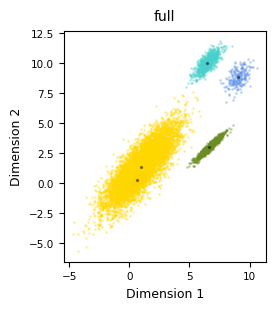

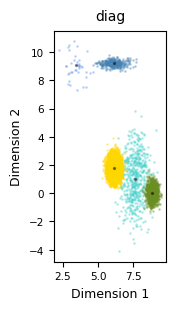

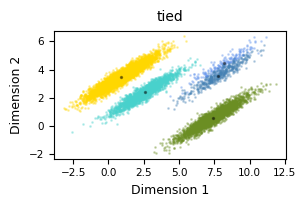

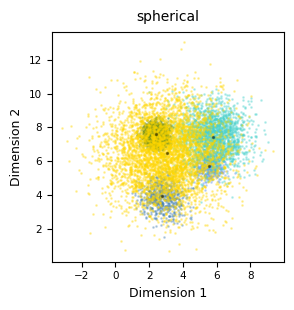

In [30]:
N_SAMPLES = 10000
colors = ["cornflowerblue", "steelblue", "mediumturquoise", "olivedrab", "gold", "goldenrod", "slategrey"]
cov_types = ["full", "diag", "tied", "spherical"]

for cov_type in cov_types:   
    mix = generate_mixture(n_samples=N_SAMPLES, k=5,
                       dirichlet_scale_foctor=1.0,
                       mean_spread=10,
                       covariance_type=cov_type,
                       cov_scale_factor=np.array([0.1, 0.2, 0.5, 1, 3, 5, 10]),
                       error_std=0.1)

    demo = plot_mixture(mix, colors=colors[:5],
                    figsize=(3,3),
                    plot_probs=False,
                    legend=False,
                    plot_type="synthetic",
                    custom_scatter_title=cov_type,
                    s=0.5)
    display(demo)

In [ ]:
RANDOM_STATE = 42
TOL = 1e-5
MAX_ITER = 1000

mixture = generate_mixture(n_samples=N_SAMPLES, k=7,
                           dirichlet_scale_foctor=1.0,
                           mean_spread=10,
                           covariance_type="full",
                           cov_scale_factor=np.array([0.1, 0.2, 0.5, 1, 3, 5, 10]),
                           error_std = 0.5)
data = mixture.data

gmm = GaussianMixture(n_components=7,
                      covariance_type="full",
                      tol=TOL,
                      max_iter=MAX_ITER,
                      init_params="k-means++",
                      warm_start=False,
                      verbose=0,
                      random_state=RANDOM_STATE)
labels = gmm.fit_predict(data)
print(f"Model fit converged: {gmm.converged_} | n_iter = {gmm.n_iter_}")

if gmm.converged_:
    # soft_assign = gmm.predict_proba(data)
    fitted = Mixture(mixture.k, gmm.weights_, labels, gmm.means_, gmm.covariances_, data)

Model fit converged: True | n_iter = 236


Note that unsupervised learning clustering labels are arbitrary.
Here cluster labels are re-sorted byprobability in ascending order for (potentially / heuristically) better alignment with the original synthetic data.


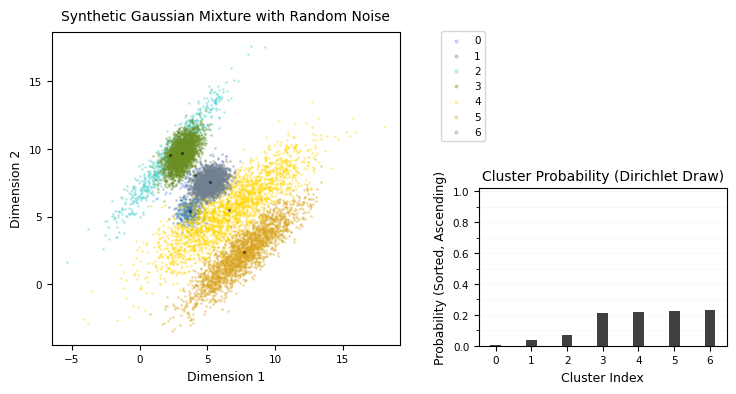

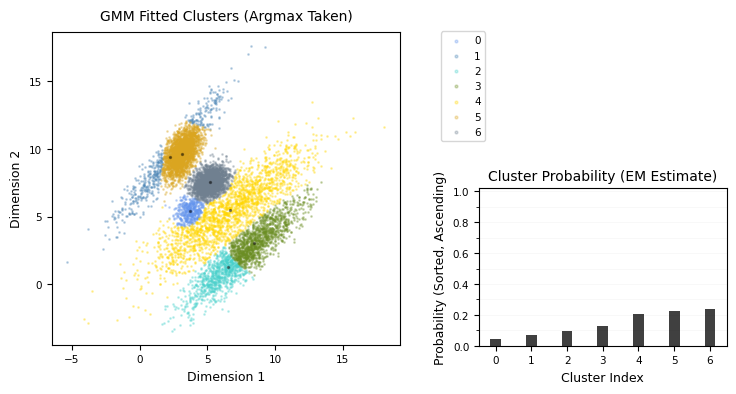

In [60]:
colors = ["cornflowerblue", "steelblue", "mediumturquoise", "olivedrab", "gold", "goldenrod", "slategrey"]

fig_synthetic = plot_mixture(mixture, colors=colors,
                             add_axes_rect=(1.075, 0.145, 0.55, 0.35),
                             figsize=(4.5,4.5),
                             plot_type="synthetic",
                             bbox_to_anchor=(1.1, 0.855),
                             s=0.5)

fig_fitted = plot_mixture(fitted, colors=colors,
                          add_axes_rect=(1.075, 0.145, 0.55, 0.35),
                          figsize=(4.5,4.5),
                          plot_type="fitted",
                          bbox_to_anchor=(1.1, 0.855),
                          s=0.5,
                          verbose=True)

display(fig_synthetic)
display(fig_fitted)


In [28]:
N_FOLDS = 5

k_grid = [4, 5, 6, 7, 8, 9]
cov_types = ["full", "diag", "tied", "spherical"]
n_init_grid = [1, 2, 3]
init_params_grid = ["kmeans", "k-means++", "random", "random_from_data"]

param_grid = {"n_components": k_grid,
              "covariance_type": cov_types,
              "n_init": n_init_grid,
              "init_params": init_params_grid
              }

searcher = GridSearchCV(GaussianMixture(
                                tol=TOL,
                                random_state=RANDOM_STATE,
                                max_iter=MAX_ITER,
                                warm_start=False
                        ),
                        param_grid=param_grid,
                        scoring=None,  # use model default (averge log likelihood of the samples under the model)
                                       # NOTE that highe held-out log-likelihood soe NOT necessarily mean the clustering 
                                       # is linguistically meaningful; it only means the model fits the data well
                                       # under the model's indictive bias (i.e., insofar as a Gaussian-mixture density
                                       # is a useful approximation for the data)
                        cv=N_FOLDS,
                        refit=False,
                        return_train_score=True)
searcher.fit(data)

best_params = searcher.best_params_
best_score, cv_results = searcher.best_score_, searcher.cv_results_

print(f"Best Params:")
display(best_params)

Best Params:


{'covariance_type': 'full',
 'init_params': 'random',
 'n_components': 6,
 'n_init': 2}

In [62]:
best_gmm = GaussianMixture(tol=TOL,
                           random_state=RANDOM_STATE,
                           max_iter=MAX_ITER,
                           warm_start=False,
                           covariance_type=best_params["covariance_type"],
                           init_params=best_params["init_params"],
                           n_components=best_params["n_components"],
                           n_init=best_params["n_init"])

labels = best_gmm.fit_predict(data)
print(f"Model fit converged: {best_gmm.converged_} | n_iter = {best_gmm.n_iter_}")

if best_gmm.converged_:
    soft_assign = best_gmm.predict_proba(data)
    fitted_cv = Mixture(best_params["n_components"], best_gmm.weights_, labels, best_gmm.means_, best_gmm.covariances_, data)

Model fit converged: True | n_iter = 155


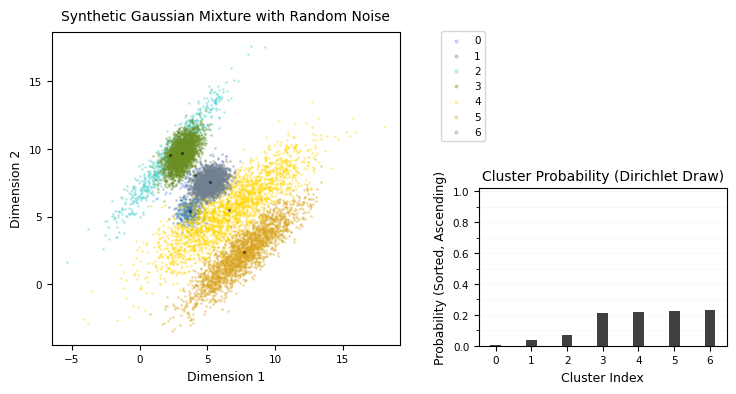

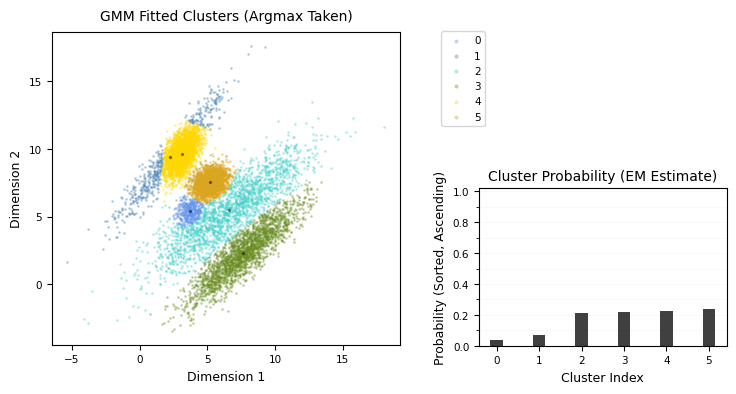

In [54]:
fig_cv = plot_mixture(fitted_cv, colors=colors[:6],
                      add_axes_rect=(1.075, 0.145, 0.55, 0.35),
                      figsize=(4.5,4.5),
                      plot_type="fitted",
                      bbox_to_anchor=(1.1, 0.855),
                      s=0.5,
                      verbose=False)

fig_synthetic.axes[0].text = "Here's the synthetic data again"
display(fig_synthetic)
display(fig_cv)

soft_assign.shape (n_samples, n_fitted_clusters) = (10000, 6)


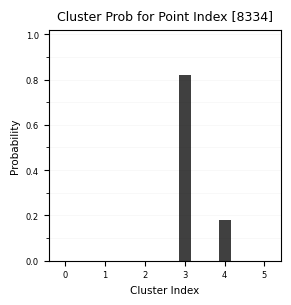

In [81]:
print(f"soft_assign.shape (n_samples, n_fitted_clusters) = {soft_assign.shape}")
idx = random.choice(range(N_SAMPLES))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))

ax.bar(range(best_params["n_components"]), soft_assign[idx],
               width=0.3, color="black", alpha=0.75)
ax.set_xticks(range(best_params["n_components"]))
ax.set_ylim(0.0, 1.02)
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.set_axisbelow(True)
ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1, axis="y")
ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0, axis="y")
ax.set_xlabel("Cluster Index", fontsize=7.5)
ax.set_ylabel("Probability", fontsize=7.5)
ax.tick_params(axis="both", which="major", labelsize=6)
ax.set_title(f"Cluster Prob for Point Index [{idx}]", fontsize=9, y=1.01)

plt.show()